In [ ]:
# Install dependencies
!pip install -q yfinance pandas numpy pydantic requests markdown matplotlib

In [ ]:
import os

REPO_URL = "https://github.com/ThemalLakruwan/CDAZZDEV-MLE-ThemalDeSilva.git"
REPO_DIR = "/content/CDAZZDEV-MLE-ThemalDeSilva"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

os.chdir(f"{REPO_DIR}/task1_financial")
print("Working directory:", os.getcwd())

Cloning into '/content/CDAZZDEV-MLE-ThemalDeSilva'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 61 (delta 23), reused 57 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 22.52 KiB | 7.51 MiB/s, done.
Resolving deltas: 100% (23/23), done.
Working directory: /content/CDAZZDEV-MLE-ThemalDeSilva/task1_financial


In [ ]:
import os
from google.colab import userdata
os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")
os.environ["TICKER"] = "AAPL"

## Task 1A — Financial Data Pipeline

In [ ]:
import importlib
import config, data_pipeline
importlib.reload(config); importlib.reload(data_pipeline)

pipeline_result = data_pipeline.run_pipeline(config.TICKER)
pipeline_result.summary

{'ticker': 'AAPL',
 'company_name': 'Apple Inc.',
 'current_price': 324.96,
 '52_week_high': 344.27,
 '52_week_low': 225.12,
 'trailing_pe': 37.31,
 'ytd_return_pct': 20.23,
 'momentum_signal': 'bullish',
 'indicators': {'sma_50': 313.38,
  'sma_200': 282.89,
  'rsi_14': 60.95,
  'macd_line': 1.95,
  'macd_signal': 0.2,
  'macd_hist': 1.75,
  'bb_upper': 324.62,
  'bb_middle': 311.99,
  'bb_lower': 299.36},
 'as_of_date': '2026-09-02'}

In [ ]:
print(f"Fetched {len(pipeline_result.ohlcv)} trading days and {len(pipeline_result.headlines)} headlines\n")
for h in pipeline_result.headlines[:10]:
    print("-", h.title)

Fetched 502 trading days and 10 headlines

- Apple facing $2.7 billion UK lawsuit over 'unfair' app tracking rules
- Tim Cook's Legacy at Apple Will Be Defined by This Nearly $879 Billion Investment, Not AI
- Warren Buffett’s biggest bet has a dividend secret
- How many employees does UnitedHealth have in 2026? Locations & layoffs explained
- Apple's new CEO faces his first big test
- US judge rejects bid to break up Google's ad business
- Apple May Need a Foldable iPhone to Avoid a Revenue Slowdown Next Year
- Apple CEO John Ternus Has a Big AI Opportunity: BofA Sees ‘Device Dominance’ Ahead, Eyes Nearly 20% Upside for AAPL
- The $277 Billion That GOOGL Stock Quietly Paid Its Owners
- Is Microsoft Stock Winning The Move To The Cloud Or Just The AI Boom?


In [ ]:
pipeline_result.ohlcv[["Close","SMA_50","SMA_200","RSI_14","macd_line","macd_signal","bb_upper","bb_lower"]].tail(10)

,Close,SMA_50,SMA_200,RSI_14,macd_line,macd_signal,bb_upper,bb_lower
Date,,,,,,,,
2026-08-20 00:00:00-04:00,311.299988,309.633345,280.822091,49.048243,-1.484022,-1.039804,340.955985,289.782967
2026-08-21 00:00:00-04:00,309.350006,309.993770,281.028542,47.398604,-1.498573,-1.131558,338.553354,289.847296
2026-08-24 00:00:00-04:00,310.339996,310.293065,281.235011,48.348409,-1.413923,-1.188031,334.866358,290.906323
2026-08-25 00:00:00-04:00,309.899994,310.673482,281.438782,47.934132,-1.366587,-1.223742,329.371168,293.412819
2026-08-26 00:00:00-04:00,313.450012,311.019191,281.662147,51.541873,-1.030736,-1.185141,323.205467,297.133663
2026-08-27 00:00:00-04:00,314.579987,311.331147,281.897637,52.666159,-0.665717,-1.081256,316.941733,301.541128
2026-08-28 00:00:00-04:00,319.700012,311.811248,282.152644,57.479998,0.036288,-0.857747,318.792046,300.796433
2026-08-31 00:00:00-04:00,316.850006,312.193184,282.364380,54.177109,0.358527,-0.614492,319.434156,301.523467
2026-09-01 00:00:00-04:00,325.130005,312.760703,282.626392,61.159868,1.267421,-0.238110,322.338413,300.220871


## Task 1B — LLM Sentiment & Signal Reasoning

In [ ]:
import llm_reasoning
importlib.reload(llm_reasoning)

client = llm_reasoning.GroqClient()
sentiment_results, aggregate_sentiment = llm_reasoning.analyze_headlines(
    client, config.TICKER, pipeline_result.headlines
)
print(f"Aggregate sentiment score: {aggregate_sentiment:+.3f}\n")
for r in sentiment_results:
    print(f"[{r.sentiment:>8}] ({r.confidence:.2f})  {r.headline}\n    -> {r.brief_reason}\n")

ERROR:llm_reasoning:LLM call failed (attempt 1): OpenRouter error: {'message': 'Upstream idle timeout exceeded', 'code': 504}


Aggregate sentiment score: +0.088

[negative] (0.85)  Apple facing $2.7 billion UK lawsuit over 'unfair' app tracking rules
    -> Large-scale lawsuit alleges antitrust violations in core business model.

[positive] (0.75)  Tim Cook's Legacy at Apple Will Be Defined by This Nearly $879 Billion Investment, Not AI
    -> The headline frames a massive $879 billion investment as the defining factor for Cook's legacy, implying a significant strategic commitment that could drive future value.

[positive] (0.75)  Warren Buffett’s biggest bet has a dividend secret
    -> Implication of a dividend secret suggests potential shareholder value enhancement for AAPL.

[ neutral] (0.95)  How many employees does UnitedHealth have in 2026? Locations & layoffs explained
    -> Headline references UnitedHealth employee data, not Apple.

[ neutral] (0.85)  Apple's new CEO faces his first big test
    -> Headline announces leadership change but provides no outcome or specific impact on stock performance.



In [ ]:
trade_signal = llm_reasoning.generate_trade_signal(
    client, config.TICKER, pipeline_result.summary, aggregate_sentiment, len(sentiment_results)
)
if trade_signal is not None:
    print("Signal:", trade_signal.signal)
    print("\nJustification:", trade_signal.justification)
    print("\nKey factors:", trade_signal.key_factors)
else:
    print("Trade signal generation failed -- check the ERROR log above for the root cause.")

Signal: Buy

Justification: AAPL is in a strong bullish trend, trading above both the 50-day and 200-day SMAs with a positive MACD crossover and expanding histogram, while RSI at 60.95 indicates healthy momentum without entering overbought territory. Price near the upper Bollinger Band suggests the trend is intact, though a touch above the middle band warrants caution for a short-term pullback. The neutral news sentiment (0.088) provides a mild headwind but does not outweigh the technically constructive setup.

Key factors: ['Price above 50-day and 200-day SMAs confirming a robust uptrend', 'MACD line well above signal with positive histogram confirming momentum', 'RSI at 60.95 showing strong but not overbought bullish momentum']


Metric,Value
Current Price,$324.96
52-Week High,$344.27
52-Week Low,$225.12
Trailing P/E,37.31
YTD Return,20.23%
Momentum Signal,Bullish
Indicator,Value
SMA 50,313.38
SMA 200,282.89
RSI (14),60.95

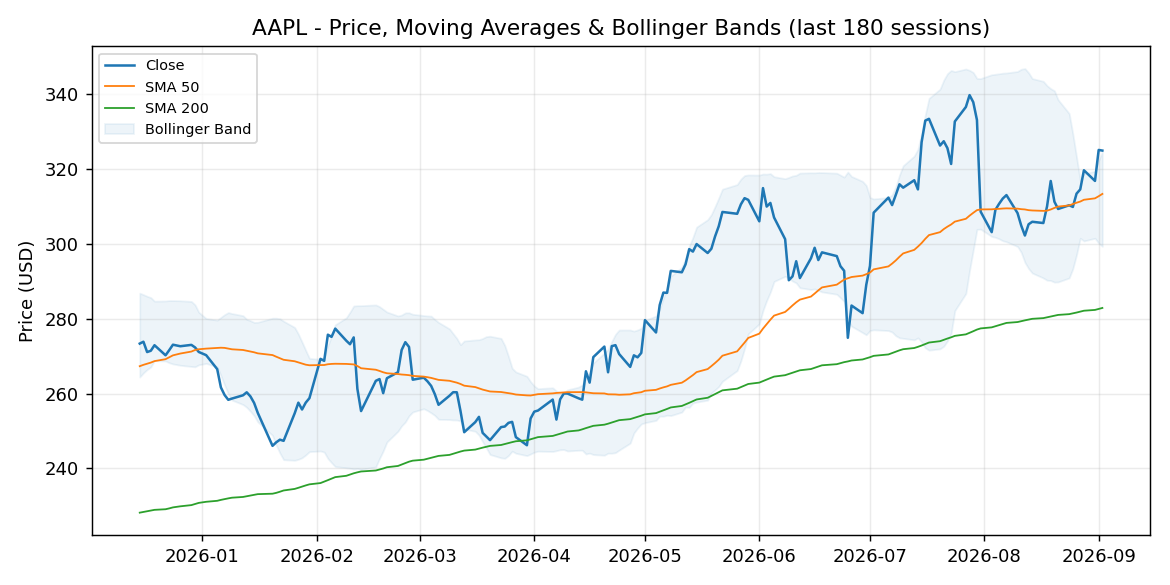

In [ ]:
import report_generator
importlib.reload(report_generator)
import os
from IPython.display import HTML, display

md_report = report_generator.build_markdown_report(
    pipeline_result.summary, sentiment_results, aggregate_sentiment, trade_signal
)
os.makedirs("output", exist_ok=True)
with open(f"output/{config.TICKER}_research_brief.md", "w") as f:
    f.write(md_report)

html_path = report_generator.render_html_report(
    md_report, pipeline_result.ohlcv, config.TICKER, f"output/{config.TICKER}_research_brief.html"
)
display(HTML(open(html_path).read()))